# Efficient Transformer Systems: MHA vs GQA vs MQA vs MLA

**Completed controlled prototype experiment · nanoGPT/GPT-2 decoder · training and autoregressive inference**

> This is an engineering research project rather than a completed academic study. I implemented the attention and cache paths from scratch, completed a controlled small-scale comparison, and use its limitations to define the next experiment.

## 1. Research question

**Under a fixed nanoGPT/GPT-2 training budget, how do Multi-Head Attention (MHA), Grouped-Query Attention (GQA), Multi-Query Attention (MQA), and Multi-Head Latent Attention (MLA) trade language-model quality for training and autoregressive inference efficiency?**

This matters because autoregressive decoding repeatedly reads the attention cache. At longer contexts, cache capacity and memory bandwidth can constrain batch size and latency even when model weights fit in memory. A useful attention mechanism must therefore be evaluated as a system, not only as an equation.

## 2. Experimental object and controlled variables

All variants use the same GPT-2-style decoder skeleton: learned token and positional embeddings, pre-norm residual blocks, GELU MLPs, tied input/output embeddings, and the same character-level Shakespeare corpus. Only the attention parameterization and its cache representation change.

| Variant | Query representation | Cached representation per layer and token | Expected cache scaling |
|---|---|---|---|
| MHA | $H$ query heads | $H$ key heads + $H$ value heads | $2Hd_h = 2d$ |
| GQA | $H$ query heads | $H_{kv}<H$ shared key/value heads | $2H_{kv}d_h$ |
| MQA | $H$ query heads | one shared key head + one shared value head | $2d_h$ |
| MLA | $H$ query heads | one learned latent vector of rank $r$ | $r$ |

MQA was proposed in [Fast Transformer Decoding: One Write-Head is All You Need](https://arxiv.org/abs/1911.02150). It is the $H_{kv}=1$ endpoint of GQA: **multi-query does not mean one query head**; all query heads remain distinct.

![Attention architecture comparison](../results/attention_architectures.png)

The comparison follows the conceptual organization of Figure 3 in the DeepSeek-V2 paper, redrawn for this experiment's four-query-head configuration and its actual cache layouts.

Controlled: dataset split and hash, tokenizer, seed, train batches, model depth/width, context length, optimizer, learning rate, batch size, number of training tokens, evaluation batches, and inference token sequence. Parameter count is reported rather than forced to match, because reducing projection parameters is part of each mechanism's systems effect.

### Scope of the MLA implementation

Multi-head Latent Attention was introduced by DeepSeek-AI in the [DeepSeek-V2 paper](https://arxiv.org/abs/2405.04434), first submitted to arXiv on 7 May 2024. The lab implements **MLA-style latent K/V compression** inside the shared GPT-2 skeleton. A down-projection produces one normalized latent per token; K and V are reconstructed by separate up-projections. The cache stores the latent, not reconstructed heads.

For experimental control, all variants retain GPT-2 learned positional embeddings. This is not a claim of exact DeepSeek MLA parity: decoupled RoPE, weight absorption, quantized caches, and fused deployment kernels are out of scope. Consequently, this implementation can reduce cache memory without reducing latency — an explicit part of the hypothesis.

## 3. Hypotheses

1. **KV-sharing memory–quality hypothesis:** GQA and MQA will reduce cache memory in proportion to their KV-head counts (2× and 4× here); more aggressive sharing may trade away validation quality.
2. **MLA memory–latency hypothesis:** MLA will produce the smallest cache, but the unfused reconstruction path will not necessarily beat MHA/GQA latency.
3. **Context-scaling hypothesis:** KV caching will provide a larger decode speedup as prompt length increases, because full recomputation repeatedly projects and attends over the prefix.

## 4. Metrics and decision criteria

**Training / quality:** train and validation cross-entropy, validation perplexity, tokens/second, parameter count. Perplexity is `exp(cross-entropy)`: lower is better, and it can be read loosely as the model's effective number of plausible next-token choices. Here it is character-level perplexity, so it is comparable across these four models but not directly to models using a different tokenizer.

**Inference:** prefill latency, p50 and p95 cached decode latency per token, p50 full-recomputation latency per token, cached tokens/second, cache bytes, and decode speedup. Timings are synchronized around complete operations. Each inference configuration has warm-up runs and seven measured repetitions; the order alternates to reduce systematic thermal bias.

**Correctness gate:** for every attention type, token-by-token cached logits must match the last-token logits from full causal recomputation within numerical tolerance. The experiment is not accepted if this gate fails.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'research').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from research.experiment import ExperimentConfig, default_data_path, run_experiment
from research.plot_experiment import (
    plot_attention_architectures, plot_inference, plot_long_context,
    plot_tradeoffs, plot_training, write_summary,
)

RESULTS_PATH = PROJECT_ROOT / 'results' / 'attention_systems_cpu.json'
FIGURE_DIR = PROJECT_ROOT / 'results'
FORCE_RERUN = False  # Set True to repeat the fixed-budget experiment.
plot_attention_architectures(FIGURE_DIR)

In [2]:
lab_config = ExperimentConfig(
    steps=250, eval_interval=50, eval_batches=12,
    batch_size=16, train_context=64,
    block_size=192, n_layer=2, n_head=4, n_embd=128,
    gqa_n_kv_heads=2, mla_latent_rank=32,
    inference_prompt_lengths=(32, 64, 128),
    inference_decode_tokens=32, inference_repeats=7,
    num_threads=1, seed=2026,
)

if FORCE_RERUN:
    results = run_experiment(default_data_path(), RESULTS_PATH, lab_config)
else:
    results = json.loads(RESULTS_PATH.read_text())

pd.Series(results['environment'], name='value').to_frame()

,value
timestamp_utc,2026-07-22T14:27:46.648570+00:00
python,3.14.2
torch,2.10.0
platform,macOS-26.5.1-arm64-arm-64bit-Mach-O
machine,arm64
processor,arm
device,cpu
cuda_available,False
mps_available,False
torch_num_threads,1


## 5. Training comparison

Each model sees exactly 256,000 training tokens. Validation is evaluated on deterministic batches at the same checkpoints. This is a small fixed-compute experiment: the goal is to compare behavior and systems trade-offs, not to claim converged language-model quality.

In [3]:
training_rows = []
for variant in results['variants']:
    training_rows.append({
        'variant': variant['variant'],
        'parameters': variant['parameter_count'],
        'attention_parameters': variant['attention_parameter_count'],
        'training_tokens': variant['training_tokens'],
        'tokens_per_second': round(variant['training_tokens_per_second']),
        'final_val_loss': round(variant['final_validation_loss'], 3),
        'final_val_perplexity': round(variant['final_validation_perplexity'], 2),
    })
pd.DataFrame(training_rows).set_index('variant')

,parameters,attention_parameters,training_tokens,tokens_per_second,final_val_loss,final_val_perplexity
variant,,,,,,
MHA,427392,131072,256000,52256,2.469,11.81
GQA,394624,98304,256000,51351,2.476,11.89
MQA,378240,81920,256000,52263,2.475,11.88
MLA,386560,90240,256000,52556,2.502,12.21


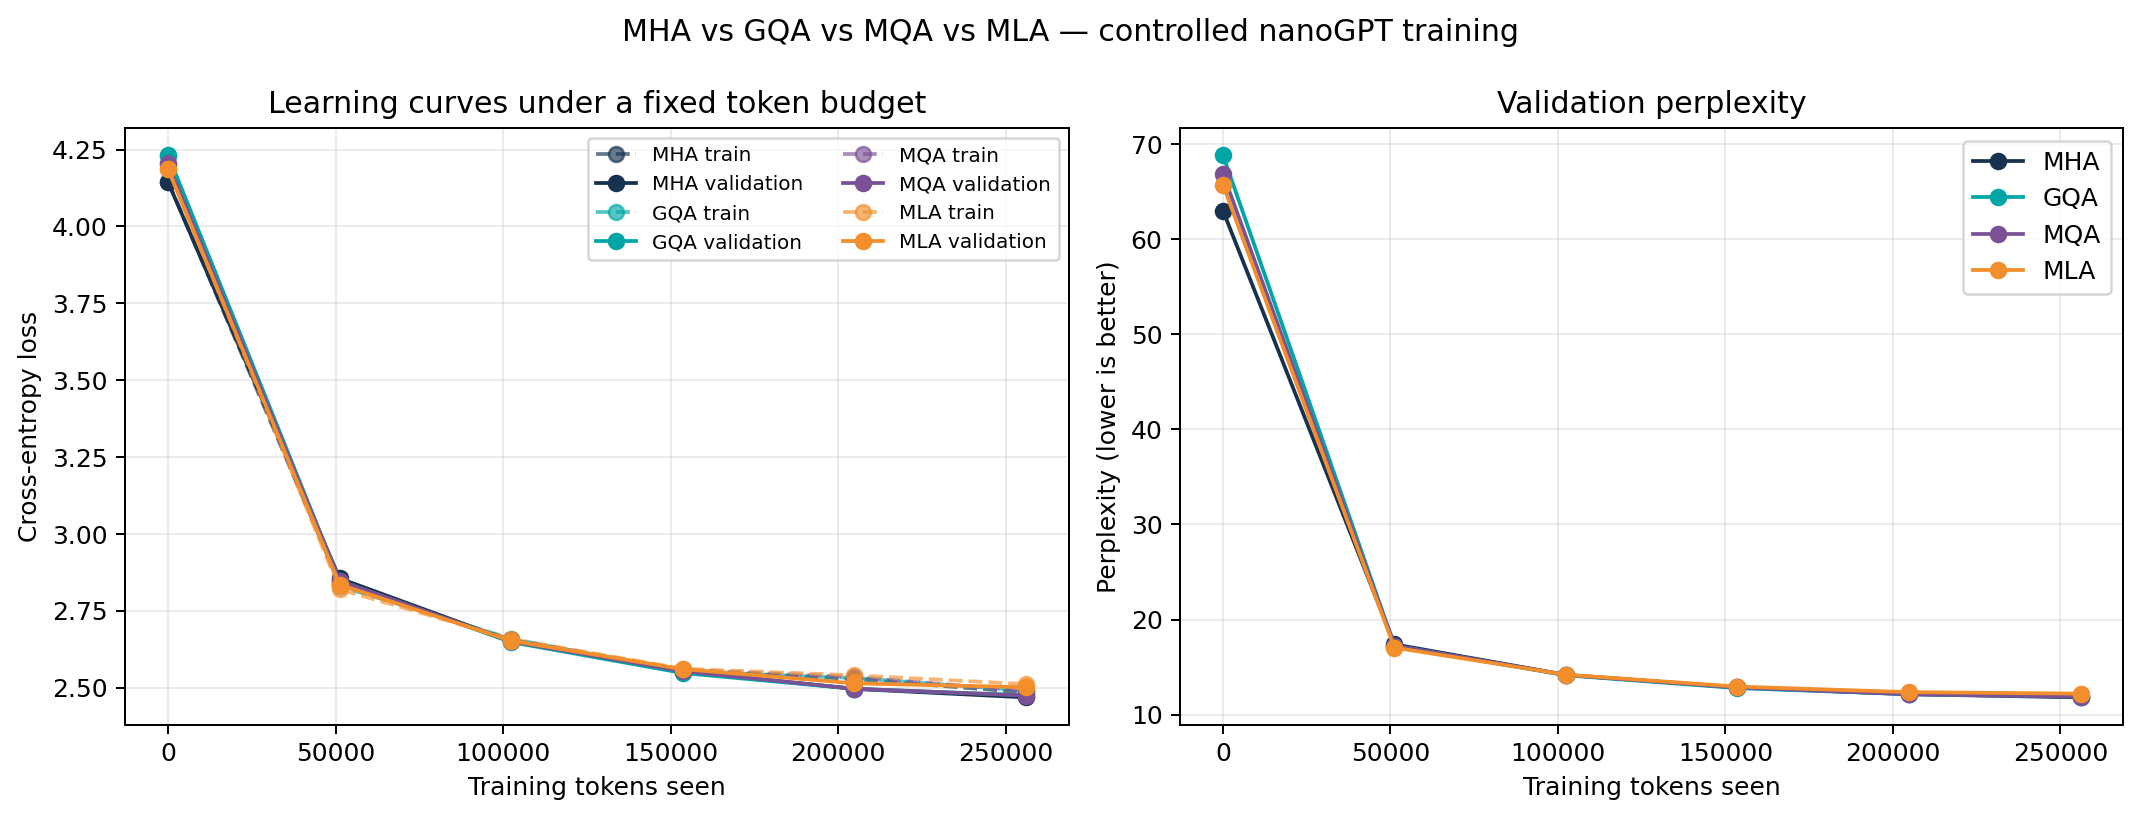

In [4]:
plot_training(results, FIGURE_DIR)
display(Image(filename=FIGURE_DIR / 'training_curves.png'))

### Training observation

All four variants learn smoothly under the same schedule. At 256k tokens, MHA reaches 11.81 validation perplexity, GQA 11.89, MQA 11.88, and MLA 12.21. The result supports a quality–memory trade-off rather than an absolute ranking: GQA and MQA are within about 0.7% of MHA in this run, while the latent bottleneck costs about 3.4%. The small reversal between GQA and MQA is not evidence that stronger sharing improves quality; a single seed is insufficient for a statistical claim.

## 6. Autoregressive inference comparison

Two paths process the same held-out token sequence:

- **full recomputation:** the complete prefix is forwarded for every next token;
- **cached decoding:** the prompt is prefetched once and each subsequent step receives one token, with a preallocated per-layer cache.

MHA caches all K/V heads, GQA caches two K/V heads, MQA caches one shared K/V pair, and MLA caches only its latent. GQA and MQA expand shared heads only for the generic attention kernel; MLA reconstructs K/V on demand.

In [5]:
longest_prompt = max(
    row['prompt_length'] for variant in results['variants'] for row in variant['inference']
)
inference_rows = []
for variant in results['variants']:
    row = next(item for item in variant['inference'] if item['prompt_length'] == longest_prompt)
    inference_rows.append({
        'variant': variant['variant'],
        'cached_ms/token': round(row['cached_decode_ms_per_token']['p50'], 3),
        'recompute_ms/token': round(row['recompute_decode_ms_per_token']['p50'], 3),
        'decode_speedup': f"{row['decode_speedup_p50']:.2f}x",
        'cache_KiB': round(row['cache_occupied_bytes'] / 1024, 1),
    })
pd.DataFrame(inference_rows).set_index('variant')

,cached_ms/token,recompute_ms/token,decode_speedup,cache_KiB
variant,,,,
MHA,0.205,1.468,7.17x,320.0
GQA,0.224,1.492,6.65x,160.0
MQA,0.234,1.515,6.48x,80.0
MLA,0.232,1.519,6.55x,40.0


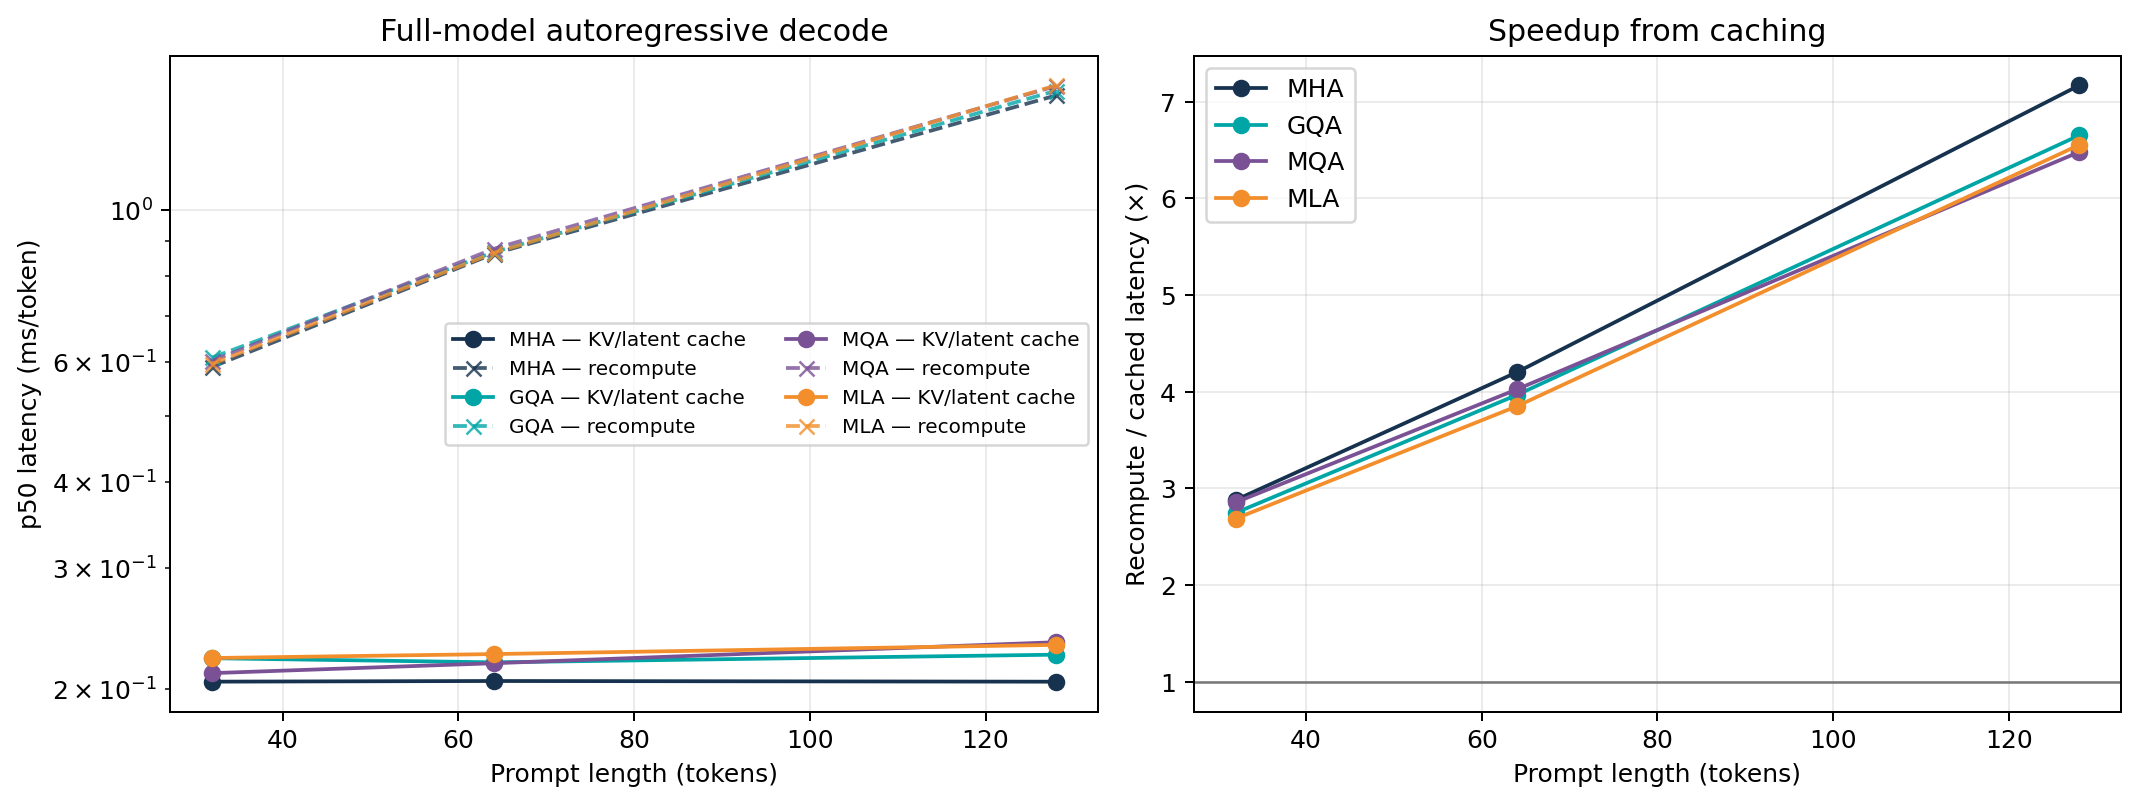

In [6]:
plot_inference(results, FIGURE_DIR)
display(Image(filename=FIGURE_DIR / 'inference_latency.png'))

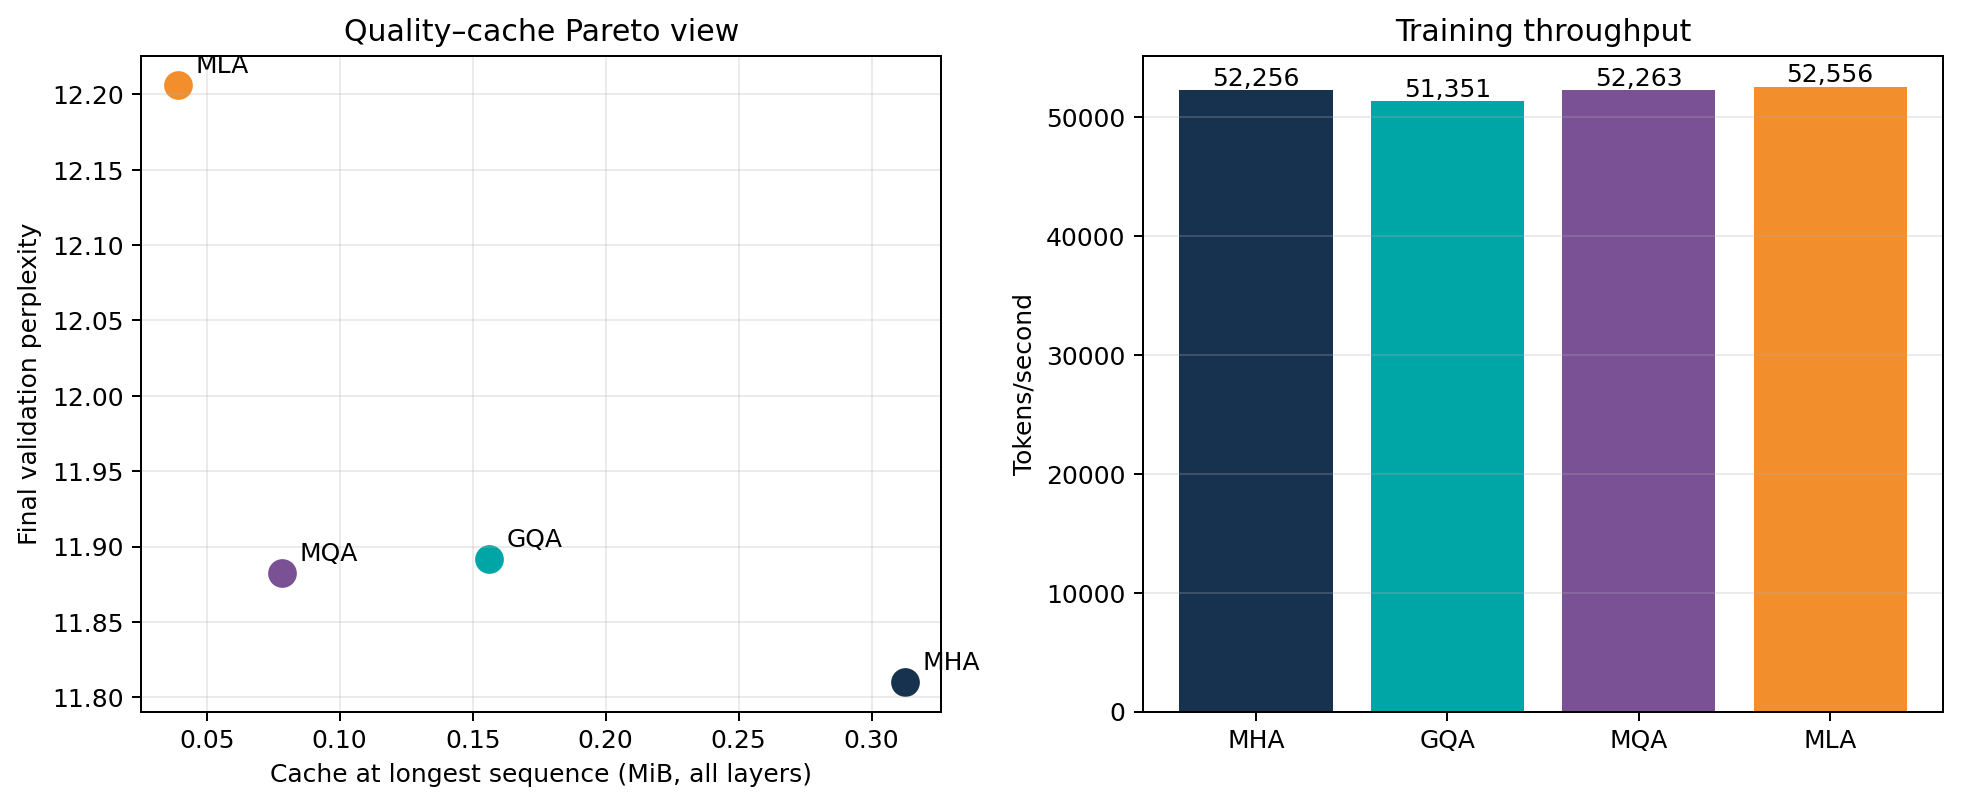

In [7]:
plot_tradeoffs(results, FIGURE_DIR)
write_summary(results, FIGURE_DIR)
display(Image(filename=FIGURE_DIR / 'quality_efficiency.png'))

## 7. Long-context capacity: where MLA wins

The latency benchmark above stops inside the trained model window. To isolate the long-context systems advantage, the next figure projects the exact persistent-cache byte formulas from 128 to 128K cached tokens. The colored `X` markers are the actual cache tensor sizes measured at 160 tokens; lines beyond the model's 192-token window are analytical.

The relative advantages are constant rather than increasing: MQA is 4× smaller and this MLA-style latent cache is 8× smaller than MHA at every length. What grows with context is the **absolute memory saved** and, therefore, the number of concurrent sequences that fit under a fixed cache budget. No long-context perplexity or latency claim is made.

cache_MiB  sequences_per_1_gib
context variant                                
32K     MHA           64.0                   16
        GQA           32.0                   32
        MQA           16.0                   64
        MLA            8.0                  128
128K    MHA          256.0                    4
        GQA          128.0                    8
        MQA           64.0                   16
        MLA           32.0                   32

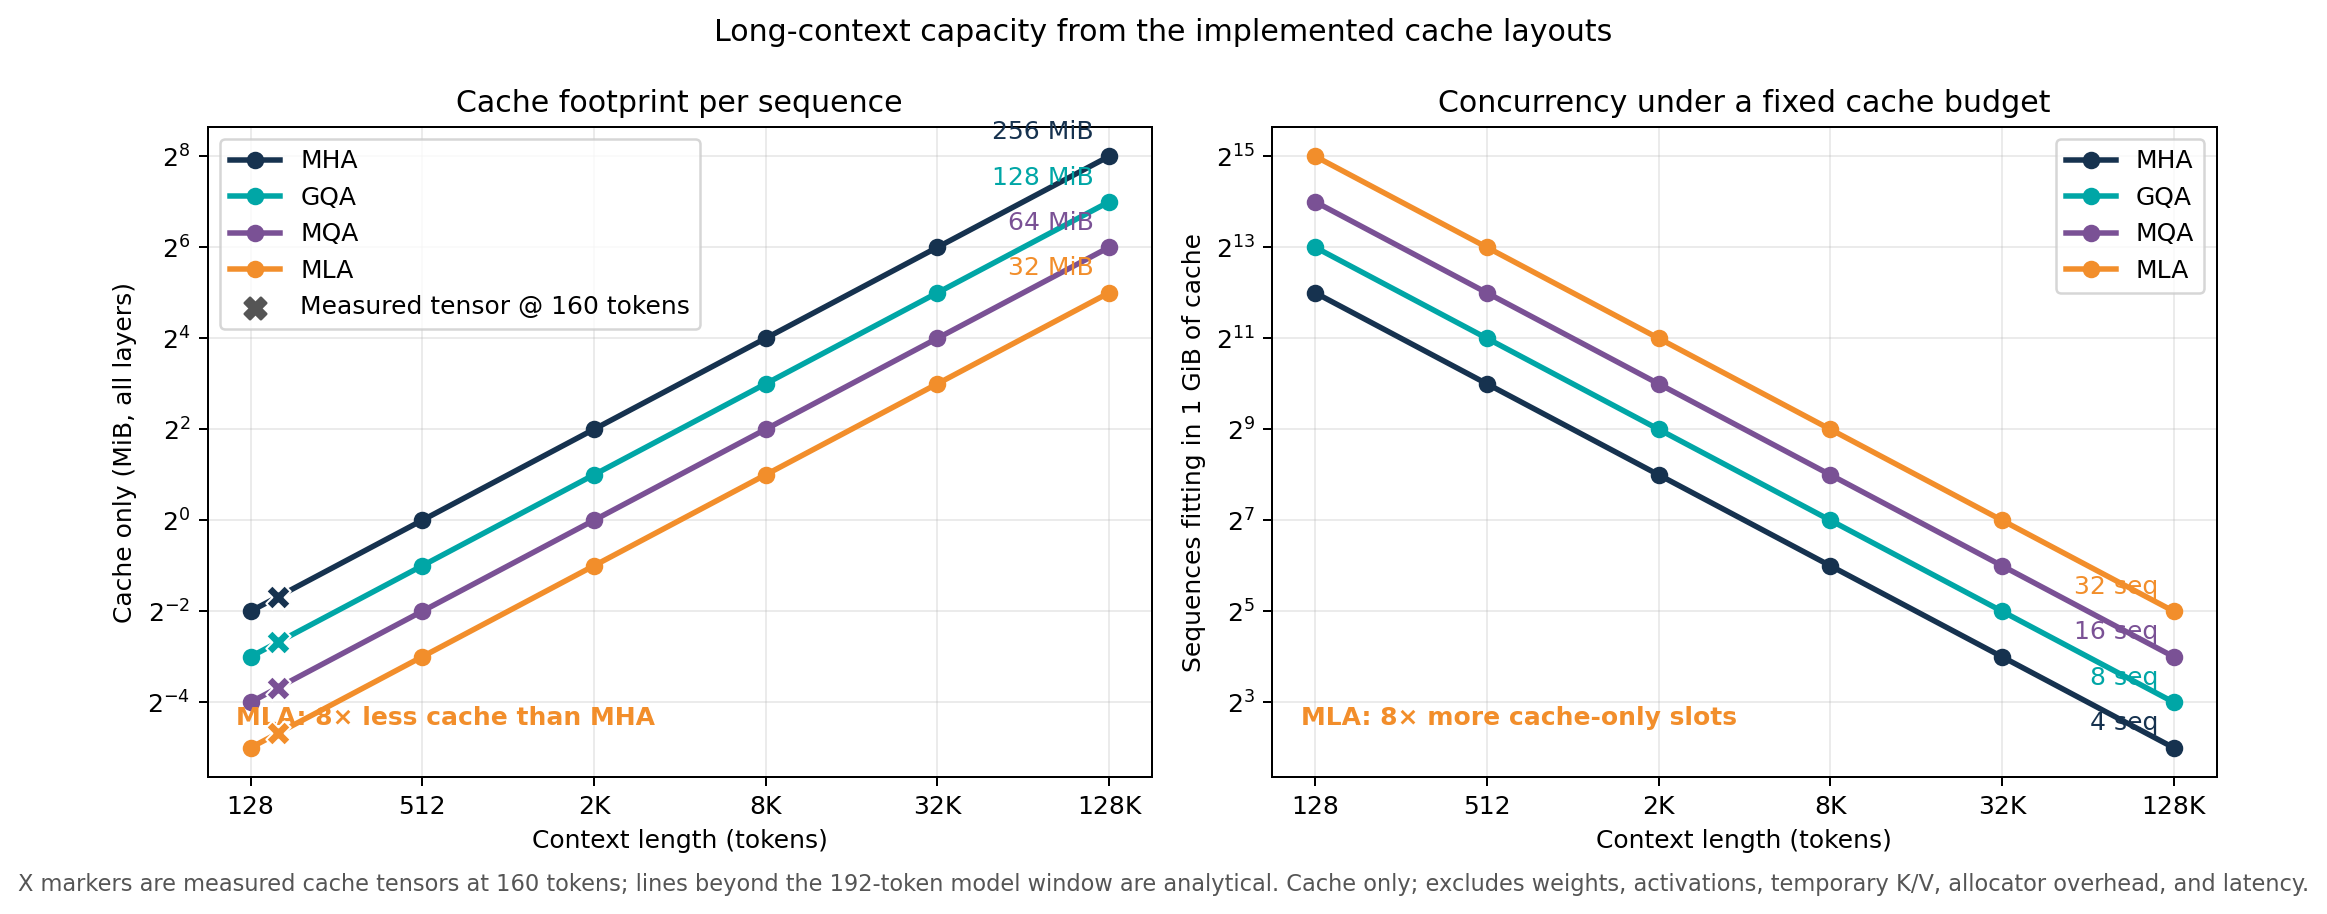

In [8]:
projection_rows = plot_long_context(results, FIGURE_DIR)
projection = pd.DataFrame(projection_rows)
selected = projection[projection['context_tokens'].isin([32_768, 131_072])].copy()
selected['context'] = selected['context_tokens'].map({32_768: '32K', 131_072: '128K'})
selected['cache_MiB'] = selected['cache_mib'].round(1)
display(selected[['context', 'variant', 'cache_MiB', 'sequences_per_1_gib']].set_index(['context', 'variant']))
display(Image(filename=FIGURE_DIR / 'long_context_capacity.png'))

## 8. Findings against the hypotheses

1. **KV-sharing memory–quality — supported in this run.** GQA uses 2× less cache than MHA (160 vs 320 KiB) and MQA uses 4× less (80 KiB); their validation perplexities remain close to MHA (11.89 and 11.88 vs 11.81).
2. **MLA memory–latency — supported.** The rank-32 latent cache is 8× smaller than MHA (40 vs 320 KiB), but generic cached decode is about 9.8% slower than MHA (0.224 vs 0.205 ms/token). Compression alone is not kernel acceleration.
3. **Context scaling — supported.** MHA's decode speedup from caching grows from the shortest prompt to 7.17× at 128 tokens; GQA, MQA, and MLA show the same monotonic trend.

**Engineering conclusion:** MQA makes the KV-sharing continuum explicit: at 128K it requires 64 MiB and fits 16 cache-only sequences per 1 GiB, versus 256 MiB and 4 for MHA. MLA creates the strongest cache-capacity result at 32 MiB and 32 sequences. None of the compact variants beats MHA latency in the generic kernel path; realizing that benefit requires optimized execution.

## 9. Limitations and threats to validity

- One small character-level dataset, one seed, 256k training tokens, and non-converged models; quality differences are directional, not statistically established.
- CPU FP32 measurements on one machine; GPU results can change ordering because kernels, memory bandwidth, and synchronization differ.
- GQA and MQA use explicit head expansion for a generic PyTorch attention kernel. MLA reconstructs K/V and does not use weight absorption or a fused kernel.
- The MLA-style controlled variant retains GPT-2 learned positional embeddings and omits decoupled RoPE; it should not be presented as a reproduction of the complete DeepSeek architecture.
- Parameter counts are reported but not matched. A matched-parameter sweep is needed to separate parameter capacity from attention structure.
- Timed contexts stop at a 128-token prompt. Points beyond the 192-token model window are exact cache-storage projections, not end-to-end executions; they exclude weights, activations, temporary reconstructed K/V, allocator overhead, latency, and long-context quality.

## 10. Next experiments

1. Run 3–5 seeds and report confidence intervals for loss/perplexity and latency.
2. Train to convergence at matched parameter budgets, then sweep `n_kv_heads` from MHA through GQA to MQA and sweep `mla_latent_rank` to estimate a quality–memory Pareto frontier.
3. Add RoPE to every variant, then implement decoupled RoPE for MLA so positional treatment remains controlled.
4. Benchmark CUDA BF16/FP16 at 1k–16k contexts with optimized GQA/MQA kernels, FlashAttention-compatible paths, and batch-size sweeps.
5. Implement MLA weight absorption/fused decoding and compare it with the explicit reconstruction baseline.
6. Combine GQA/MQA/MLA with 8-bit and 4-bit cache quantization, measuring both perplexity and memory bandwidth.
7. Extend the systems track to DDP/FSDP/DeepSpeed while keeping this single-device experiment as the correctness baseline.

## 11. What I implemented personally

- a shared GPT-2/nanoGPT decoder with interchangeable MHA, GQA, MQA, and MLA-style modules;
- preallocated compact KV and latent caches, including offset-aware causal masking;
- cached-vs-full numerical correctness tests;
- deterministic fixed-token training and validation;
- synchronized inference measurement with warm-up, repetitions, p50/p95, and raw JSON;
- plots and a reproducible notebook that distinguish measured results from limitations.

**Interview summary:** I asked whether modern attention mechanisms actually improve the quality–memory–latency trade-off inside the same decoder. I implemented four variants and their caches, trained them under the same budget, verified cached correctness, and measured both quality and systems metrics. GQA halved cache, MQA reduced it fourfold, and MLA reduced it eightfold. None accelerated the generic compact-cache path over MHA, showing that an algorithmic memory improvement becomes a systems speedup only when the execution path exploits it.

## Reproduce from the project root

```bash
make test
make attention-experiment
make attention-plots
```

The committed JSON contains raw repeated timings, environment metadata, dataset SHA-256, all hyperparameters, and every training checkpoint metric. Set `FORCE_RERUN = True` above to rerun from this notebook.